In [1]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 

In [3]:
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

temp = 1
device = torch.device("cpu")
model_m = SpliceFormer(CL_max,determenistic=True, crop=True)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

n_models = 10

# models = [copy.deepcopy(model_m) for i in range(n_models)]
# [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
# for model in models:
#     model.eval()


model_m.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_3',map_location=device))
model_m.eval()


DataParallel(
  (module): SpliceFormer(
    (SpliceAI): SpliceAI(
      (conv_layer_1): Conv1d(4, 32, kernel_size=(1,), stride=(1,))
      (skip_layers): ModuleList(
        (0-4): 5 x Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      )
      (res_layers): ModuleList(
        (0): ResComboBlock(
          (comboBlock): Sequential(
            (0): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (activate): ReLU(inplace=True)
              (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (shortcut): Identity()
            )
            (1): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d

In [4]:
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

In [39]:
OUT_MAP = np.asarray([[1, 0, 0],
                      [0, 1, 0],
                      [0, 0, 1],
                      [0, 0, 0]])

IN_MAP = np.asarray([[1, 0, 0, 0],
                      [0, 1, 0, 0],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]])


# -

def getData(data_dir,setType):
    if setType == 'train':
        chroms = ['chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21',
                               'chr2', 'chr4', 'chr6', 'chr8', 'chr10', 'chr12',
                               'chr14', 'chr16', 'chr18', 'chr20', 'chr22', 'chrX', 'chrY']
    if setType == 'test':
        chroms = ['chr1', 'chr3', 'chr5', 'chr7', 'chr9']
    if setType == 'all':
        chroms = ['chr11', 'chr13', 'chr15', 'chr17', 'chr19','chr1', 'chr21',
                               'chr2', 'chr4', 'chr6', 'chr8', 'chr10', 'chr12',
                               'chr14', 'chr16', 'chr18', 'chr20', 'chr22', 'chr3', 'chr5', 'chr7', 'chr9', 'chrX', 'chrY']
    if setType == 'all':
        with open('{}/sparse_discrete_label_data_train.pickle'.format(data_dir), 'rb') as handle:
            transcriptToLabel = pickle.load(handle)
        with open('{}/sparse_discrete_label_data_test.pickle'.format(data_dir), 'rb') as handle:
            transcriptToLabel2 = pickle.load(handle)
            transcriptToLabel.update(transcriptToLabel2)
    else:
        with open('{}/sparse_discrete_label_data_{}.pickle'.format(data_dir,setType), 'rb') as handle:
            transcriptToLabel = pickle.load(handle)
    
    if setType == 'all':
        annotation1 = pd.read_csv(data_dir+'/annotation_ensembl_v87_train.txt',sep='\t',header=None)[[0,1,2,3,4]]
        annotation2 = pd.read_csv(data_dir+'/annotation_ensembl_v87_test.txt',sep='\t',header=None)[[0,1,2,3,4]]
        annotation = pd.concat([annotation1,annotation2],axis=0)
    else:
        annotation = pd.read_csv(data_dir+'/annotation_ensembl_v87_{}.txt'.format(setType),sep='\t',header=None)[[0,1,2,3,4]]
    annotation.columns = ['name','chrom','strand','tx_start','tx_end']
    annotation['transcript'] = annotation['name'].apply(lambda x: x.split('---')[-2].split('.')[0]).values
    annotation['gene'] = annotation['name'].apply(lambda x: x.split('---')[-3].split('.')[0]).values
    #annotation['support'] = annotation['transcript'].apply(lambda x:transcriptToSupport[x])

    chrom_paths = glob(data_dir+'/sparse_sequence_data/*')
    chromToPath = {}
    for path in chrom_paths:
        chromToPath[path.split('/')[-1].split('_')[0]] = path

    seqData = {}
    for chrom in chroms:
        path = glob(data_dir+'/sparse_sequence_data/{}_*.npz'.format(chrom))[0]
        seqData[chrom] = load_npz(path).tocsr()
    return annotation,transcriptToLabel,seqData

class DataPoint:
    def __init__(self, transcript,gene,chrom,strand,start,end,tx_start,tx_end,splice_loc,splice_type,SL,CL_max,shift,mask_n):
        self.transcript = transcript
        self.gene = gene
        self.chrom = chrom
        self.strand = strand
        self.start = start
        self.end = end
        self.tx_start = tx_start
        self.tx_end = tx_end
        self.splice_loc = splice_loc
        self.splice_type = splice_type
        self.SL = SL
        self.CL_max = CL_max
        self.shift = shift
        self.mask_n = mask_n
        
    def getData(self,seqData):
        X = np.zeros((4,self.SL+self.CL_max))
        Y = np.zeros((3,self.SL))
        
        low = np.max([self.tx_start,self.start-self.CL_max//2])
        low_diff = low-self.start+self.CL_max//2
        high = np.min([self.tx_end,self.end+self.CL_max//2])
        high_diff = high-(self.end+self.CL_max//2)
        X[:,low_diff:self.CL_max+self.SL+high_diff] = seqData[self.chrom][low-1:high,:4].toarray().T
        Y[0,:(self.SL-self.mask_n)] = np.ones(self.SL-self.mask_n)
        Y[:,self.splice_loc-self.shift] = OUT_MAP[np.array(self.splice_type).astype('int8')].T
        #X = seqData[self.chrom][self.start-1:self.end,:4].toarray().T
        if self.strand=='-':
            X = X[:,::-1]
            X = X[::-1,:]
        return X.copy(),Y.copy()
    
def getDataPointList(annotation,transcriptToLabel,SL,CL_max,shift):
    data = []
    for idx in range(annotation.shape[0]):
        transcript,gene,chrom,strand,tx_start,tx_end = annotation['transcript'].values[idx], annotation['gene'].values[idx],annotation['chrom'].values[idx],annotation['strand'].values[idx],annotation['tx_start'].values[idx],annotation['tx_end'].values[idx]
        length = tx_end-tx_start+1
        num_points = ceil_div(length, shift)
        label = [np.array(x) for x in transcriptToLabel[transcript]]

        for i in range(num_points):
            if strand=='+':
                start,end = tx_start+shift*i,tx_start+SL+shift*(i)-1
                if i == 0:
                    start_point = start
                inRange = [l>=start-start_point and l<=end-start_point for l in label[1]]
                mask_n = np.max([end,tx_end])-tx_end
                data.append(DataPoint(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start-start_point,mask_n))
            else:
                start,end = tx_end-SL-shift*i+1,tx_end-shift*i
                if i == 0:
                    start_point = end
                inRange = [l>=start_point-end and l<= start_point-start for l in label[1]]
                mask_n = tx_start-np.min([start,tx_start])
                data.append(DataPoint(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start_point-end,mask_n))
    return data

class DataPointFull:
    def __init__(self, transcript,gene,chrom,strand,start,end,tx_start,tx_end,splice_loc,splice_type,SL,CL_max,shift,mask_l,mask_r,include_pos=False):
        self.transcript = transcript
        self.gene = gene
        self.chrom = chrom
        self.strand = strand
        self.start = start
        self.end = end
        self.tx_start = tx_start
        self.tx_end = tx_end
        self.splice_loc = splice_loc
        self.splice_type = splice_type
        self.SL = SL
        self.CL_max = CL_max
        self.shift = shift
        self.mask_l = mask_l
        self.mask_r = mask_r
        self.include_pos = include_pos
        
    def getData(self,seqData):
        X = np.zeros((4,self.SL+self.CL_max))
        r = np.zeros((self.SL+self.CL_max))
        Y = np.zeros((3,self.SL+self.CL_max))
        
        #low = np.max([self.tx_start,self.start-self.CL_max//2])
        #low_diff = low-self.start+self.CL_max//2
        #high = np.min([self.tx_end,self.end+self.CL_max//2])
        #high_diff = high-(self.end+self.CL_max//2)
        #X[:,low_diff:self.CL_max+self.SL+high_diff] = seqData[self.chrom][low-1:high,:4].toarray().T
        if self.include_pos:
            pos = np.arange(self.start-1,self.end)
            chrm = np.repeat(self.chrom,self.SL)
            transcript = np.repeat(self.transcript,self.SL)
        
        if self.strand=='+':
            print(seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_l:self.end+self.CL_max//2-self.mask_r,:4].toarray().T)
            print('\n')
            X[:,self.mask_l:self.SL+self.CL_max-self.mask_r] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_l:self.end+self.CL_max//2-self.mask_r,:4].toarray().T
            r[self.mask_l:self.SL+self.CL_max-self.mask_r] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_l:self.end+self.CL_max//2-self.mask_r,4].toarray()[:,0]
        else:
            X[:,self.mask_r:self.SL+self.CL_max-self.mask_l] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_r:self.end+self.CL_max//2-self.mask_l,:4].toarray().T
            r[self.mask_r:self.SL+self.CL_max-self.mask_l] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_r:self.end+self.CL_max//2-self.mask_l,4].toarray()[:,0]
            X = X[:,::-1]
            r = r[::-1]
            X = X[::-1,:]
        Y[0,self.mask_l:(self.SL+self.CL_max-self.mask_r)] = np.ones(self.SL+self.CL_max-self.mask_r-self.mask_l)
        Y[:,self.splice_loc-self.shift+self.CL_max//2] = OUT_MAP[np.array(self.splice_type,dtype=np.int8)].T
        r_sum = np.sum(r)
        if r_sum>0:
            Y[:,r==1] =  OUT_MAP[3*np.ones(int(r_sum),dtype=np.int8)].T
        
        if self.include_pos:
            return X.copy(),Y.copy(),pos,chrm,transcript
        else:
            return X.copy(),Y.copy()
    
def getDataPointListFull(annotation,transcriptToLabel,SL,CL_max,shift,include_pos=False):
    data = []
    for idx in range(annotation.shape[0]):
        transcript,gene,chrom,strand,tx_start,tx_end = annotation['transcript'].values[idx], annotation['gene'].values[idx],annotation['chrom'].values[idx],annotation['strand'].values[idx],annotation['tx_start'].values[idx],annotation['tx_end'].values[idx]
        length = tx_end-tx_start+1
        num_points = ceil_div(length, shift)
        label = [np.array(x) for x in transcriptToLabel[transcript]]
        for i in range(num_points):
            if strand=='+':
                start,end = tx_start+shift*i,tx_start+SL+shift*(i)-1
                if i == 0:
                    start_point = start
                inRange = [l>=start-start_point-CL_max//2 and l<=end-start_point+CL_max//2 for l in label[1]]
                mask_l = tx_start-np.min([start-CL_max//2,tx_start])
                mask_r = np.max([end+CL_max//2,tx_end])-tx_end
                # print(inRange)
                data.append(DataPointFull(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start-start_point,mask_l,mask_r,include_pos))
            else:
                start,end = tx_end-SL-shift*i+1,tx_end-shift*i
                if i == 0:
                    start_point = end
                inRange = [l>=start_point-end-CL_max//2 and l<= start_point-start+CL_max//2 for l in label[1]]
                mask_l =  np.max([end+CL_max//2,tx_end])-tx_end
                mask_r = tx_start-np.min([start-CL_max//2,tx_start])
                data.append(DataPointFull(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start_point-end,mask_l,mask_r,include_pos))
    return data


# -

def getDataPointListSeqFull(annotation,transcriptToLabel,SL,CL_max,shift,tokenizer,include_pos=False):
    data = []
    for idx in range(annotation.shape[0]):
        transcript,gene,chrom,strand,tx_start,tx_end = annotation['transcript'].values[idx], annotation['gene'].values[idx],annotation['chrom'].values[idx],annotation['strand'].values[idx],annotation['tx_start'].values[idx],annotation['tx_end'].values[idx]
        length = tx_end-tx_start+1
        num_points = ceil_div(length, shift)
        label = [np.array(x) for x in transcriptToLabel[transcript]]

        for i in range(num_points):
            if strand=='+':
                start,end = tx_start+shift*i,tx_start+SL+shift*(i)-1
                if i == 0:
                    start_point = start
                inRange = [l>=start-start_point-CL_max//2 and l<=end-start_point+CL_max//2 for l in label[1]]
                mask_l = tx_start-np.min([start-CL_max//2,tx_start])
                mask_r = np.max([end+CL_max//2,tx_end])-tx_end
                print(inRange)
                print(mask_l)
                print(mask_r)
                data.append(DataPointSeqFull(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start-start_point,mask_l,mask_r,tokenizer,include_pos))
            else:
                start,end = tx_end-SL-shift*i+1,tx_end-shift*i
                if i == 0:
                    start_point = end
                inRange = [l>=start_point-end-CL_max//2 and l<= start_point-start+CL_max//2 for l in label[1]]
                mask_l =  np.max([end+CL_max//2,tx_end])-tx_end
                mask_r = tx_start-np.min([start-CL_max//2,tx_start])
                data.append(DataPointSeqFull(transcript,gene,chrom,strand,start,end,tx_start,tx_end,label[1][inRange],label[0][inRange],SL,CL_max,start_point-end,mask_l,mask_r,tokenizer,include_pos))
    return data


class DataPointSeqFull:
    def __init__(self, transcript,gene,chrom,strand,start,end,tx_start,tx_end,splice_loc,splice_type,SL,CL_max,shift,mask_l,mask_r,tokenizer,include_pos=False):
        self.transcript = transcript
        self.gene = gene
        self.chrom = chrom
        self.strand = strand
        self.start = start
        self.end = end
        self.tx_start = tx_start
        self.tx_end = tx_end
        self.splice_loc = splice_loc
        self.splice_type = splice_type
        self.SL = SL
        self.CL_max = CL_max
        self.shift = shift
        self.mask_l = mask_l
        self.mask_r = mask_r
        self.include_pos = include_pos
        self.tokenizer = tokenizer
        
    def one_hot_to_sequence(self,one_hot_array):
        # Define mapping of indices to bases
        bases = np.array(['A', 'C', 'G', 'T', 'N'])

        # Convert transposed one-hot array to sequence indices
        sequence_indices = np.argmax(one_hot_array, axis=0)

        # Map indices to bases to get the sequence
        sequence = bases[sequence_indices]
        # Convert the array to a string
        #sequence_string = ''.join(sequence)
        return sequence

        
    def getData(self,seqData):
        X = np.zeros((4,self.SL+self.CL_max))
        r = np.zeros((self.SL+self.CL_max))
        Y = np.zeros((3,self.SL+self.CL_max))
        
        #low = np.max([self.tx_start,self.start-self.CL_max//2])
        #low_diff = low-self.start+self.CL_max//2
        #high = np.min([self.tx_end,self.end+self.CL_max//2])
        #high_diff = high-(self.end+self.CL_max//2)
        #X[:,low_diff:self.CL_max+self.SL+high_diff] = seqData[self.chrom][low-1:high,:4].toarray().T
        if self.include_pos:
            pos = np.arange(self.start-1,self.end)
            chrm = np.repeat(self.chrom,self.SL)
            transcript = np.repeat(self.transcript,self.SL)
        
        if self.strand=='+':
            print(self.mask_l)
            print(self.SL+self.CL_max-self.mask_r)
            print('\n')
            X[:,self.mask_l:self.SL+self.CL_max-self.mask_r] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_l:self.end+self.CL_max//2-self.mask_r,:4].toarray().T
            r[self.mask_l:self.SL+self.CL_max-self.mask_r] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_l:self.end+self.CL_max//2-self.mask_r,4].toarray()[:,0]
        else:
            X[:,self.mask_r:self.SL+self.CL_max-self.mask_l] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_r:self.end+self.CL_max//2-self.mask_l,:4].toarray().T
            r[self.mask_r:self.SL+self.CL_max-self.mask_l] = seqData[self.chrom][self.start-self.CL_max//2-1+self.mask_r:self.end+self.CL_max//2-self.mask_l,4].toarray()[:,0]
            X = X[:,::-1]
            r = r[::-1]
            X = X[::-1,:]
        Y[0,self.mask_l:(self.SL+self.CL_max-self.mask_r)] = np.ones(self.SL+self.CL_max-self.mask_r-self.mask_l)
        Y[:,self.splice_loc-self.shift+self.CL_max//2] = OUT_MAP[np.array(self.splice_type,dtype=np.int8)].T
        r_sum = np.sum(r)
        if r_sum>0:
            Y[:,r==1] =  OUT_MAP[3*np.ones(int(r_sum),dtype=np.int8)].T
        
        X = self.one_hot_to_sequence(X)
        #X = self.tokenizer(X)
        
        if self.include_pos:
            return X.copy(), Y.copy(), pos, chrm, transcript
        else:
            return X.copy(),Y.copy()


def label_map(val,stype):
    label = np.zeros(3)
    label[stype] = val
    label[0] = 1-val
    return label



class spliceDataset(Dataset):
    def __init__(self, annotation, transform=None, target_transform=None):
        self.annotation = annotation
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.annotation)

    def __getitem__(self, idx):
        X, Y = self.annotation[idx].getData(self.seqData)
        return X,Y

def ceil_div(x, y):
    return int(ceil(float(x)/y))

class DataLoaderWrapper:

    def __init__(self, data_loader, steps_per_epoch: int = 1000):
        self.data_loader = data_loader
        self.iterator = iter(self.data_loader)
        self.steps_per_epoch = steps_per_epoch
        self.current_step = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self.current_step < self.steps_per_epoch:
            self.current_step += 1
            try:
                return next(self.iterator)
            except StopIteration:
                self.iterator = iter(self.data_loader)
                return next(self.iterator)
        else:
            self.current_step = 0
            raise StopIteration


#+
def collate_fn(data):
    """
        data: is a list of tuples with (example, label)
                where 'example' is a tensor of arbitrary shape
                and label/length are scalars
    """
    #unfold1 = nn.Unfold((SL*3,1),SL,CL_max//2)
    #unfold2 = nn.Unfold((SL,1),SL,0)
    features = []
    labels = []
    for i in range(len(data)):
        features.append(torch.Tensor(data[i][0]))
        labels.append(torch.Tensor(data[i][1]))
        #features.append(tmp.unfold(0,SL*3,CL_max//2))
        #labels.append(torch.Tensor(data[i][1]).unfold(0,SL,CL_max//2))
        return torch.cat(features,dim=0).float(), torch.cat(labels,dim=0).float()

In [40]:
test = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test.seqData = seqData
test = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for x, y in test:
    print(x)
    print(y)


[array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1]), array([   184,  24400,  29179,  51151,  54402,  55448,  56710,  60383,
        62145,  68860,  79692, 107870, 110476, 112694, 115095, 122900,
       123819, 126790, 130706, 131845, 134750, 147807, 162630, 172968,
       184897, 185601,  24290,  29071,  50936,  54313,  55285,  56585,
        60137,  62053,  68678,  79501, 107776, 110390, 111971, 114967,
       122863, 123569, 126711, 130556, 131618, 134650, 147559, 162475,
       172879, 184725, 185496, 186945])]
[[1 1 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 1 ... 0 0 1]]


tensor([[[0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]], dtype=torch.float64)
tensor([[[0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.],
     

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [5]:
# for model in models:
#     model.module.transformerBlocks[0].layers[0][0].attend.register_forward_hook(get_activation('attend1'))
#     model.module.transformerBlocks[0].layers[1][0].attend.register_forward_hook(get_activation('attend2'))
#     model.module.transformerBlocks[0].layers[2][0].attend.register_forward_hook(get_activation('attend3'))
#     model.module.transformerBlocks[0].layers[3][0].attend.register_forward_hook(get_activation('attend4'))

model_m.module.transformerBlocks[0].layers[0][0].attend.register_forward_hook(get_activation('attend1'))
model_m.module.transformerBlocks[0].layers[1][0].attend.register_forward_hook(get_activation('attend2'))
model_m.module.transformerBlocks[0].layers[2][0].attend.register_forward_hook(get_activation('attend3'))
model_m.module.transformerBlocks[0].layers[3][0].attend.register_forward_hook(get_activation('attend4'))



In [6]:
def plotAttentionWeights(model_m,batch_features,targets,shift,name):
    output = model_m(batch_features)
    tmp = nn.Softmax(dim=1)(model_m.module.conv_final(model_m.module.SpliceAI(batch_features)))
    acceptors_sorted = torch.argsort(tmp[:,1,:],dim=1,descending=True)[:,:512//2]
    donors_sorted = torch.argsort(tmp[:,2,:],dim=1,descending=True)[:,:512//2]
    splice_idx = torch.cat([acceptors_sorted,donors_sorted],dim=1)
    splice_idx = torch.sort(splice_idx,dim=1).values.cpu().numpy()
    print(splice_idx)
    donor_idxs = torch.argsort(targets[2,:],descending=True)[:int(torch.sum(targets[2,:]))].cpu().numpy()+0-shift
    donor_idxs_2 = donor_idxs[np.where(np.logical_and(donor_idxs>=0, donor_idxs<=5000))]
    acceptor_idxs = torch.argsort(targets[1,:],descending=True)[:int(torch.sum(targets[1,:]))].cpu().numpy()+0-shift
    acceptor_idxs_2 = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=0, acceptor_idxs<=5000))]
    incl_idxs = []
    print(donor_idxs_2,acceptor_idxs_2)
    for donor_idx in donor_idxs:
        tmp = np.arange(512)[splice_idx[0,:] == donor_idx]
        if len(tmp)>0:
            incl_idxs.append(tmp[0])

    for acceptor_idx in acceptor_idxs:
        tmp = np.arange(512)[splice_idx[0,:] == acceptor_idx]
        if len(tmp)>0:
            incl_idxs.append(tmp[0])
    
    print(donor_idxs, acceptor_idxs, incl_idxs)

    attention = np.concatenate([activation['attend{}'.format(i+1)][0,:,:,:].cpu().numpy() for i in range(4)],axis=0)
    
    for i,val in enumerate(incl_idxs):
        attentionExpanded = np.zeros(45000)
        #print(val,splice_idx[0,val])
        attentionExpanded[splice_idx] = np.mean(attention[:,val,:],axis=0)

        start,end = 0,45000
        start_shift = 20000
        fig = plt.figure()
        plt.plot(range(start+shift-start_shift,end+shift-start_shift),attentionExpanded[start:end])
        a = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=start, acceptor_idxs<=end))]
        print(a)
        plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[a],attentionExpanded[a]+0.001,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
        d = donor_idxs[np.where(np.logical_and(donor_idxs>=start, donor_idxs<=end))]
        print(d)
        plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[d],attentionExpanded[d]+0.001,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
        plt.scatter([splice_idx[0,val]+shift-start_shift],attentionExpanded[splice_idx[0,val]]+0.003,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
        plt.legend()
        plt.xlabel('Directed distance from transcript start (nt)')
        plt.ylabel('Attention')
        # plt.savefig('../Results/AttentionPlots/{}_{}.png'.format(name,i), dpi=400)
        plt.show()
        plt.close()

In [87]:
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm
#norm=PowerNorm(gamma=0.1)

def plot_data(data, title, size):

    fig_width = 15  # You can tune this value
    fig_height = size  # One unit per row
    aspect_ratio = 45000 / fig_width
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Plot the data as an image
    cax = ax.imshow(data, cmap='gray', aspect='auto', interpolation='none')

    # Set y-axis labels
    ax.set_yticks([i for i in range(size)])
    if size == 4:
        labels = ['A', 'C', 'G', 'T']
    else:
        labels = ['Acceptor', 'Donor']
    ax.set_yticklabels(labels)

    # Optional: remove x-axis ticks to declutter
    ax.set_xticks([])

    # Label and display
    ax.set_xlabel('Position')
    ax.set_title(f'{title} One-hot Encoding Grid (1 = white, 0 = black)')
    plt.tight_layout()
    plt.show()
    plt.close()

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(array([20184, 44400]),)


  0%|          | 0/38 [00:00<?, ?it/s]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0,

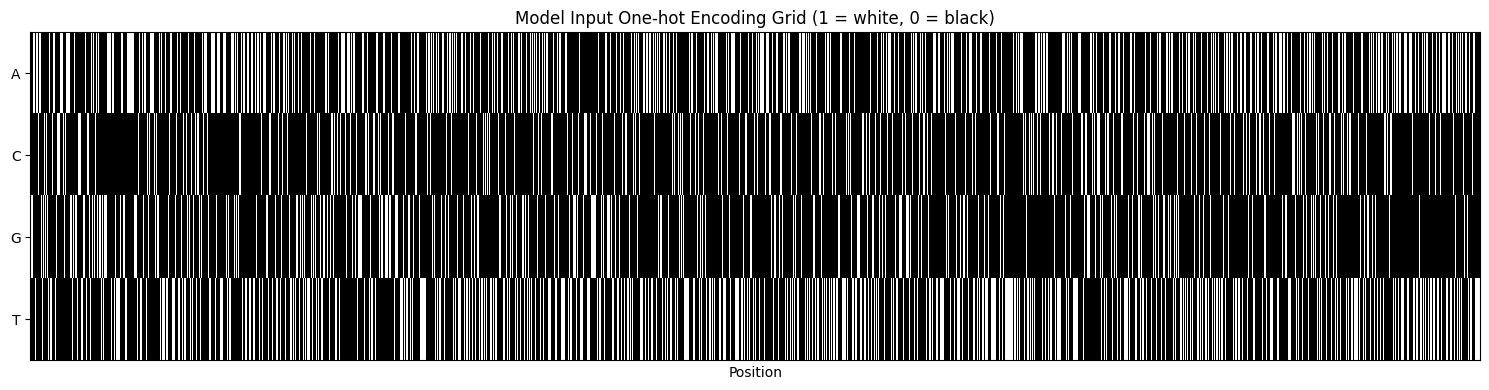

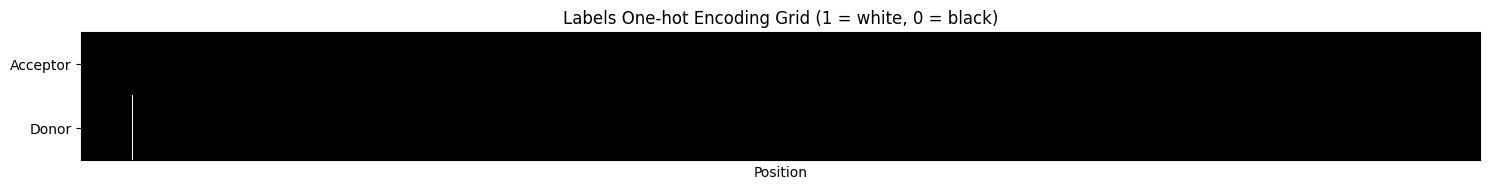

[0.964914083480835, 0.013266781345009804, 0.0020003297831863165, 0.00028950427076779306, 0.00020081772527191788, 0.00019566697301343083, 0.00012673735909629613, 0.00012064868496963754, 8.440713281743228e-05, 5.781901927548461e-05, 5.4144962632562965e-05, 5.2364081057021394e-05, 4.9095677240984514e-05, 4.633186836144887e-05, 4.4644344598054886e-05, 4.341701423982158e-05, 3.6196070141159e-05, 3.2078147341962904e-05, 3.115519939456135e-05, 3.079912858083844e-05, 2.8510465199360624e-05, 2.346213295822963e-05, 1.8265267499373294e-05, 1.730020267132204e-05, 1.613568929315079e-05, 1.4810277207288891e-05, 1.4105759873928037e-05, 1.3497216059477068e-05, 1.3478319488058332e-05, 1.2027723641949706e-05, 1.1933959285670426e-05, 1.1600458492466714e-05, 1.1222553439438343e-05, 1.1175121471751481e-05, 1.111702476919163e-05, 1.0142051905859262e-05, 9.939700248651206e-06, 9.580430742062163e-06, 9.54341703618411e-06, 9.51630590861896e-06, 9.178035725199152e-06, 8.908385098038707e-06, 8.811245606921148e-0

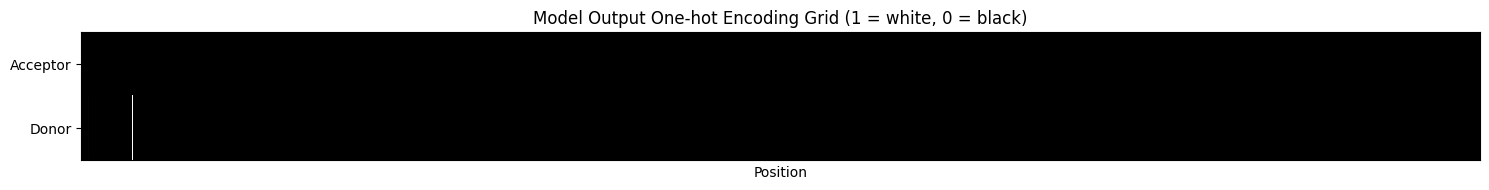

  0%|          | 0/38 [00:00<?, ?it/s]

Transcript spans: 20000 to 44999


In [88]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
all_data = list(test_loader)
print(np.nonzero(all_data[0][1][0,2,:].tolist()))
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    print(batch_chunks[0,1,20000:25000].tolist())
    print(torch.nonzero(target_chunks[0,2,20000:]))
    plot_data(batch_chunks[0,:,20000:25000], 'Model Input',4)
    plot_data(target_chunks[0,1:,20000:25000], 'Labels', 2)

    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    output = ([model_m(batch_features)[0].detach()])
    output = torch.stack(output)
    output = torch.mean(output,dim=0)
    print(output[0,2,torch.argsort(output[0,2,:], descending=True)].tolist())
    plot_data(output[0,1:,:], 'Model Output', 2)
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    # print(batch_features[0,0,:].tolist())
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    l += 1

    if l >1:
        break
    # batch_chunks = torch.transpose(batch_chunks.to(torch.float32).to(device),1,1)
    # target_chunks = torch.transpose(target_chunks.to(torch.float32).to(device),1,1)
    # batch_chunks = torch.split(batch_chunks, BATCH_SIZE, dim=0)
    # target_chunks = torch.split(target_chunks, BATCH_SIZE, dim=0)
    # targets = torch.squeeze(torch.cat(target_chunks,dim=2),dim=0)
    # for j in range(len(batch_chunks)):
    #     batch_features = batch_chunks[j]
    #     #targets = target_chunks[j]
    #     plotAttentionWeights(model_m,batch_features,targets,j*5000,'CFTR_{}'.format(j+1))

In [42]:
model_m(batch_features)
aw = [model_m.module.transformerBlocks[0].layers[i][0].last_attn.detach().cpu() for i in range(4)]
aw = torch.cat(aw, dim=1).squeeze(0).numpy()

attention = np.concatenate([activation['attend{}'.format(i+1)][0,:,:,:].cpu().numpy() for i in range(4)],axis=0)

print(np.array_equal(aw,attention))

True


Transcript spans: 0 to 44999
[  184 29179 24400] [24290 29071] [np.int64(239), np.int64(228)]
1
(array([], dtype=int64),)
[24290 29071] [  184 29179 24400]


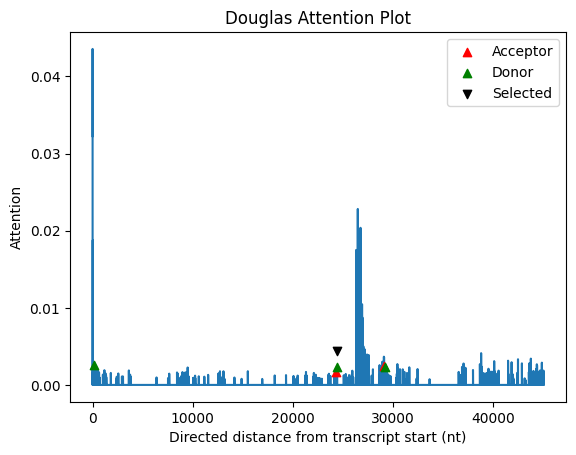

0
(array([], dtype=int64),)
[24290 29071] [  184 29179 24400]


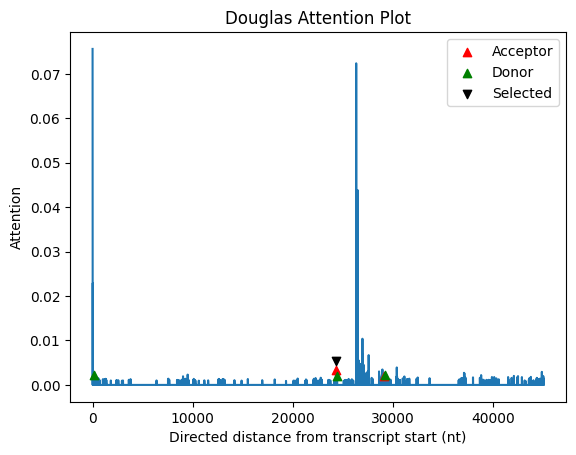

In [151]:
shift = 20000
# out,acceptor_actions,donor_actions,acceptor_log_probs,donor_log_probs = ([models[i](batch_features) for i in range(n_models)])
output,acceptor_actions,donor_actions,acceptor_log_probs,donor_log_probs = model_m(batch_features)
signal = batch_features[0].sum(dim=0)  # shape: [45000]
nonzero_positions = torch.nonzero(signal > 0).squeeze()
print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

attention = np.concatenate([activation['attend{}'.format(i+1)][0,:,:,:].cpu().numpy() for i in range(4)],axis=0)
# attention = [model_m.module.transformerBlocks[0].layers[i][0].last_attn.detach().cpu() for i in range(4)]
# attention = torch.cat(attention, dim=1).squeeze(0).numpy()

acceptors_sorted = torch.sort(acceptor_actions)[0]
donors_sorted = torch.sort(donor_actions)[0]
splice_idx = torch.cat([acceptors_sorted,donors_sorted],dim=1)
splice_idx = torch.sort(splice_idx,dim=1).values.cpu().numpy()
donor_idxs = torch.argsort(targets[2,:],descending=True)[:int(torch.sum(targets[2,:]))].cpu().numpy()
donor_idxs_2 = donor_idxs[np.where(np.logical_and(donor_idxs>=20000, donor_idxs<=25000))]
acceptor_idxs = torch.argsort(targets[1,:],descending=True)[:int(torch.sum(targets[1,:]))].cpu().numpy()
acceptor_idxs_2 = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=20000, acceptor_idxs<=25000))]
incl_idxs = []
determinant_idx = splice_idx
for donor_idx in donor_idxs_2:
    tmp = np.arange(512)[splice_idx[0,:] == donor_idx]
    if len(tmp)>0:
        incl_idxs.append(tmp[0])

for acceptor_idx in acceptor_idxs_2:
    tmp = np.arange(512)[splice_idx[0,:] == acceptor_idx]
    if len(tmp)>0:
        incl_idxs.append(tmp[0])

print(donor_idxs, acceptor_idxs, incl_idxs)
for i,val in enumerate(incl_idxs):
    mask = (splice_idx[0,:] >= 20000-shift)
    attentionExpanded = np.zeros(45000)
    attentionExpanded[splice_idx[0,:]] = np.mean(attention[:,val,:],axis=0)

    print(np.argmax(attentionExpanded))
    print(np.where(splice_idx[0,:] == 17692))
    
    start,end = 0,45000
    start_shift = 20000
    fig = plt.figure()
    plt.plot(range(start+shift-start_shift,end+shift-start_shift),attentionExpanded[start:end])
    a = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=start, acceptor_idxs<=end))]
    plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[a],attentionExpanded[a]+0.001,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
    d = donor_idxs[np.where(np.logical_and(donor_idxs>=start, donor_idxs<=end))]
    print(a,d)
    plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[d],attentionExpanded[d]+0.001,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
    plt.scatter([splice_idx[0,val]+shift-start_shift],attentionExpanded[splice_idx[0,val]]+0.003,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
    plt.legend()
    plt.title('Douglas Attention Plot')
    plt.xlabel('Directed distance from transcript start (nt)')
    plt.ylabel('Attention')
    plt.show()
    plt.close()

In [44]:
batch_features = batch_chunks.type(torch.FloatTensor).to(device)
targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
outputs = ([model_m(batch_features)[0].detach()])
print(batch_features.shape)
print(targets.shape)
#outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
outputs = torch.stack(outputs)
print(outputs.shape)
outputs = torch.mean(outputs,dim=0)
print(outputs.shape)
#outputs = odds_gmean(outputs)
#targets_list.extend(targets.unsqueeze(0))
#outputs_list.extend(outputs.unsqueeze(0))

targets = torch.transpose(targets,1,2).cpu().numpy()
outputs = torch.transpose(outputs,1,2).cpu().numpy()
print(targets.shape)
print(outputs.shape)

torch.Size([1, 4, 45000])
torch.Size([1, 3, 5000])
torch.Size([1, 1, 3, 5000])
torch.Size([1, 3, 5000])
(1, 5000, 3)
(1, 5000, 3)


In [105]:
device = torch.device("cpu")
model_m = SpliceFormer(CL_max, determenistic=True,crop=True)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)

n_models = 10

models = [copy.deepcopy(model_m) for i in range(n_models)]
[model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
for model in models:
    model.eval()

test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Y_true_acceptor, Y_pred_acceptor = [],[]
Y_true_donor, Y_pred_donor = [],[]
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.type(torch.FloatTensor).to(device)
    targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
    outputs = ([models[i](batch_features)[0].detach() for i in range(n_models)])
    #outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
    outputs = torch.stack(outputs)
    outputs = torch.mean(outputs,dim=0)
    #outputs = odds_gmean(outputs)
    #targets_list.extend(targets.unsqueeze(0))
    #outputs_list.extend(outputs.unsqueeze(0))

    targets = torch.transpose(targets,1,2).cpu().numpy()
    outputs = torch.transpose(outputs,1,2).cpu().numpy()
    is_expr = (targets.sum(axis=(1,2)) >= 1)
    Y_true_acceptor.extend(targets[is_expr, :, 1].flatten())
    Y_true_donor.extend(targets[is_expr, :, 2].flatten())
    Y_pred_acceptor.extend(outputs[is_expr, :, 1].flatten())
    Y_pred_donor.extend(outputs[is_expr, :, 2].flatten())
    # l += 1
    # if l>1:
    #     break
Y_true_acceptor, Y_pred_acceptor = np.array(Y_true_acceptor), np.array(Y_pred_acceptor)
Y_true_donor, Y_pred_donor = np.array(Y_true_donor), np.array(Y_pred_donor)

100%|██████████| 38/38 [04:02<00:00,  6.37s/it]


In [173]:
shift = 5000
output,acceptor_actions,donor_actions,acceptor_log_probs,donor_log_probs = model_m(batch_features)
signal = batch_features[0].sum(dim=0)  # shape: [45000]
nonzero_positions = torch.nonzero(signal > 0).squeeze()
print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

attention = np.concatenate([activation['attend{}'.format(i+1)][0,:,:,:].cpu().numpy() for i in range(4)],axis=0)
acceptors_sorted = torch.sort(acceptor_actions)[0]
donors_sorted = torch.sort(donor_actions)[0]
splice_idx = torch.cat([acceptors_sorted,donors_sorted],dim=1)
splice_idx = torch.sort(splice_idx,dim=1).values.cpu().numpy()
mask = (splice_idx[0,:] >= 20000-shift)
splice_idx = splice_idx[0,mask] 
print(splice_idx.shape)

donor_idxs = torch.argsort(targets[2,:],descending=True)[:int(torch.sum(targets[2,:]))].cpu().numpy() + 20000-shift
donor_idxs_2 = donor_idxs[np.where(np.logical_and(donor_idxs>=20000-shift, donor_idxs<=25000-shift))]
acceptor_idxs = torch.argsort(targets[1,:],descending=True)[:int(torch.sum(targets[1,:]))].cpu().numpy() + 20000-shift
acceptor_idxs_2 = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=20000-shift, acceptor_idxs<=25000-shift))]
incl_idxs = []
for donor_idx in donor_idxs_2:
    tmp = np.arange(len(splice_idx))[splice_idx[:] == donor_idx]
    if len(tmp)>0:
        incl_idxs.append(tmp[0])

for acceptor_idx in acceptor_idxs_2:
    tmp = np.arange(len(splice_idx))[splice_idx[:] == acceptor_idx]
    if len(tmp)>0:
        incl_idxs.append(tmp[0])

print(donor_idxs, acceptor_idxs, incl_idxs)
for i,val in enumerate(incl_idxs):
    attentionExpanded = np.zeros(45000)
    attentionExpanded[splice_idx[:]] = np.mean(attention[:,val,mask],axis=0)

    print(attentionExpanded.tolist())
    # print([splice_idx[0,val]])

    start,end = 0,45000
    start_shift = 20000
    fig = plt.figure()
    plt.plot(range(start+shift-start_shift,end+shift-start_shift),attentionExpanded[start:end])
    a = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=start, acceptor_idxs<=end))]
    plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[a],attentionExpanded[a]+0.001,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
    d = donor_idxs[np.where(np.logical_and(donor_idxs>=start, donor_idxs<=end))]
    print(a,d)
    plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[d],attentionExpanded[d]+0.001,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
    plt.scatter([splice_idx[val]+shift-start_shift],attentionExpanded[splice_idx[val]]+0.003,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
    plt.legend()
    plt.xlabel('Directed distance from transcript start (nt)')
    plt.ylabel('Attention')
    plt.show()
    plt.close()

Transcript spans: 20000 to 44999
(502,)
[35184 59400] [59290] []


In [51]:
print(len(Y_pred_donor))
d = np.where(Y_true_donor==1)
print(d)
print(Y_pred_donor[d])
print(np.where(Y_true_acceptor==1))


25000
(array([  184, 24400]),)
[0.9807366  0.97816795]
(array([24290]),)


Donor distance from transcript start:  (array([   184,  24400,  29179,  51151,  54402,  55448,  56710,  60383,
        62145,  68860,  79692, 107870, 110476, 112694, 115095, 122900,
       123819, 126790, 130706, 131845, 134750, 147807, 162630, 172968,
       184897, 185601]),)
Acceptor distance from transcript start:  (array([ 24290,  29071,  50936,  54313,  55285,  56585,  60137,  62053,
        68678,  79501, 107776, 110390, 111971, 114967, 122863, 123569,
       126711, 130556, 131618, 134650, 147559, 162475, 172879, 184725,
       185496, 186945]),)


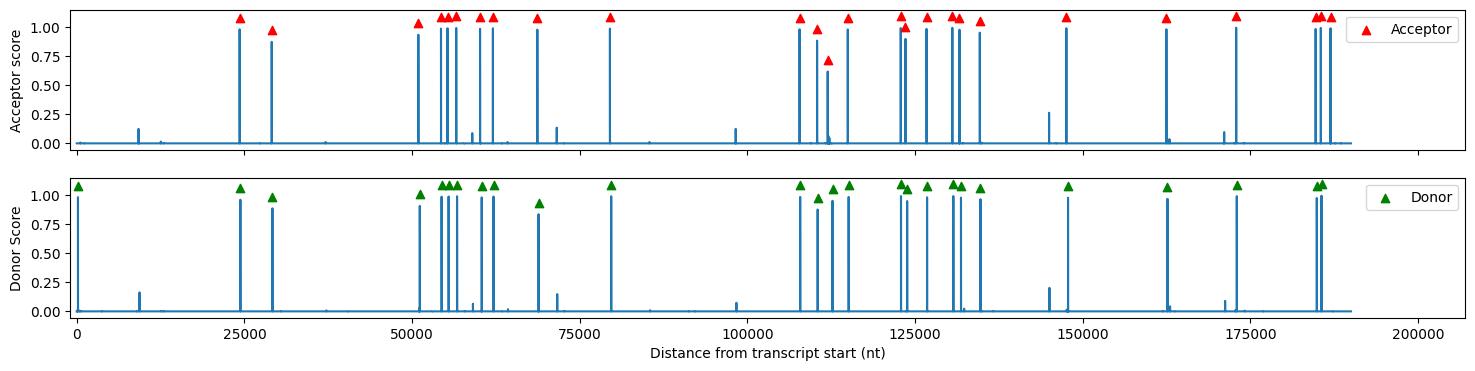

In [106]:
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(18, 4),sharex=True)
ax1.plot(Y_pred_acceptor)
ax2.plot(Y_pred_donor)
cond = (Y_true_acceptor==1)
ax1.scatter(np.where(Y_true_acceptor==1),Y_pred_acceptor[cond]+0.1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
cond = (Y_true_donor==1)
ax2.scatter(np.where(Y_true_donor==1),Y_pred_donor[cond]+0.1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax1.set_xlim([-1000,207000])
ax2.set_ylabel('Donor Score')
ax1.legend()
ax2.legend()
print('Donor distance from transcript start: ', np.where(Y_true_donor==1))
print('Acceptor distance from transcript start: ', np.where(Y_true_acceptor==1))

# plt.savefig('../Results/Transformer_CFTR_scores.png', dpi=400)
plt.show()

In [103]:
device = torch.device("cpu")
model_m = SpliceAI_10K(CL_max)
model_m.apply(keras_init)
model_m = model_m.to(device)
n_models = 10

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)

models = [copy.deepcopy(model_m) for i in range(n_models)]
[model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_071122_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
for model in models:
    model.eval()

test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Y_true_acceptor, Y_pred_acceptor = [],[]
Y_true_donor, Y_pred_donor = [],[]
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.type(torch.FloatTensor).to(device)
    targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
    outputs = ([models[i](batch_features).detach() for i in range(n_models)])
    #outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
    outputs = torch.stack(outputs)
    outputs = torch.mean(outputs,dim=0)
    #outputs = odds_gmean(outputs)
    #targets_list.extend(targets.unsqueeze(0))
    #outputs_list.extend(outputs.unsqueeze(0))

    targets = torch.transpose(targets,1,2).cpu().numpy()
    outputs = torch.transpose(outputs,1,2).cpu().numpy()

    is_expr = (targets.sum(axis=(1,2)) >= 1)
    Y_true_acceptor.extend(targets[is_expr, :, 1].flatten())
    Y_true_donor.extend(targets[is_expr, :, 2].flatten())
    Y_pred_acceptor.extend(outputs[is_expr, :, 1].flatten())
    Y_pred_donor.extend(outputs[is_expr, :, 2].flatten())

    # l += 1
    # if l>1:
    #     break
Y_true_acceptor, Y_pred_acceptor = np.array(Y_true_acceptor), np.array(Y_pred_acceptor)
Y_true_donor, Y_pred_donor = np.array(Y_true_donor), np.array(Y_pred_donor)

100%|██████████| 38/38 [23:24<00:00, 36.97s/it] 


SPLICEAI_10K
Donor distance from transcript start:  (array([   184,  24400,  29179,  51151,  54402,  55448,  56710,  60383,
        62145,  68860,  79692, 107870, 110476, 112694, 115095, 122900,
       123819, 126790, 130706, 131845, 134750, 147807, 162630, 172968,
       184897, 185601]),)
Acceptor distance from transcript start:  (array([ 24290,  29071,  50936,  54313,  55285,  56585,  60137,  62053,
        68678,  79501, 107776, 110390, 111971, 114967, 122863, 123569,
       126711, 130556, 131618, 134650, 147559, 162475, 172879, 184725,
       185496, 186945]),)


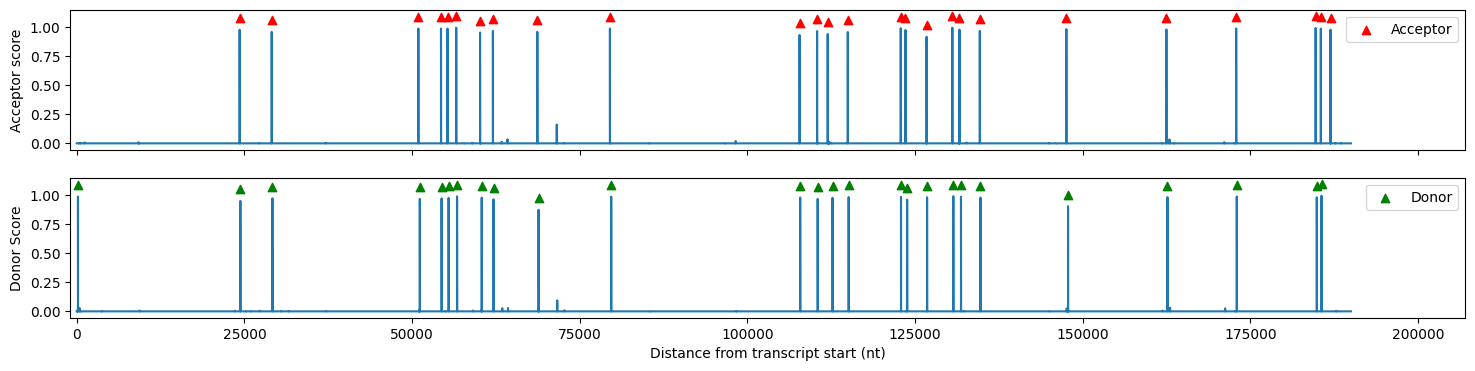

In [104]:
print('SPLICEAI_10K')
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(18, 4),sharex=True)
ax1.plot(Y_pred_acceptor)
ax2.plot(Y_pred_donor)
cond = (Y_true_acceptor==1)
ax1.scatter(np.where(Y_true_acceptor==1),Y_pred_acceptor[cond]+0.1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
cond = (Y_true_donor==1)
ax2.scatter(np.where(Y_true_donor==1),Y_pred_donor[cond]+0.1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax1.set_xlim([-1000,207000])
ax2.set_ylabel('Donor Score')
ax1.legend()
ax2.legend()
print('Donor distance from transcript start: ', np.where(Y_true_donor==1))
print('Acceptor distance from transcript start: ', np.where(Y_true_acceptor==1))

# plt.savefig('../Results/Transformer_CFTR_scores.png', dpi=400)
plt.show()

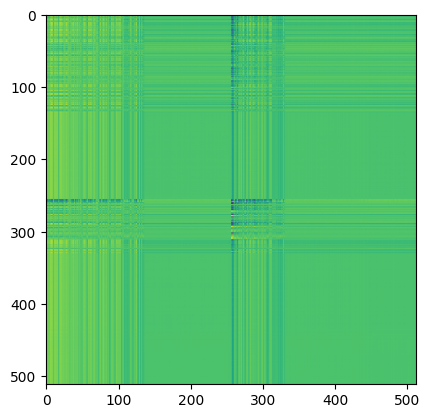

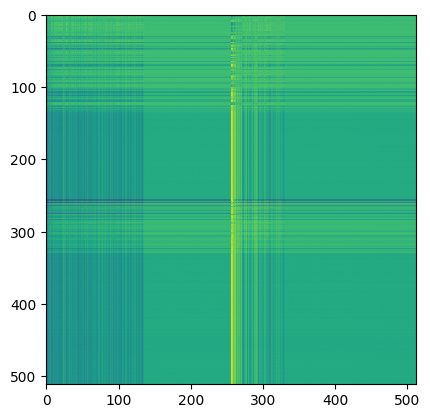

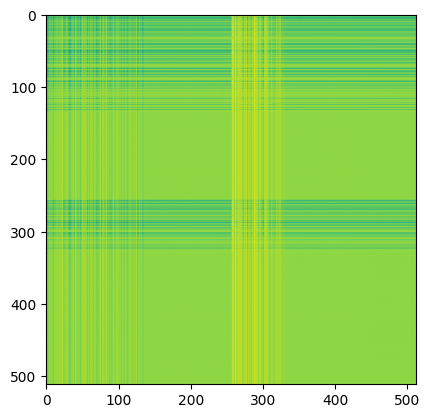

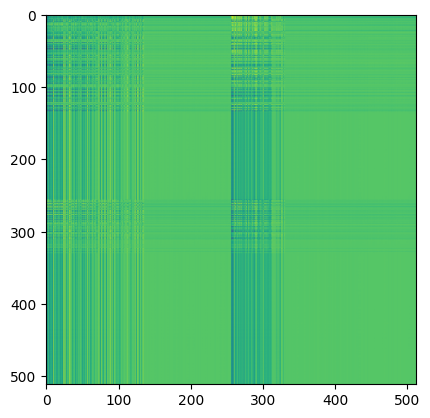

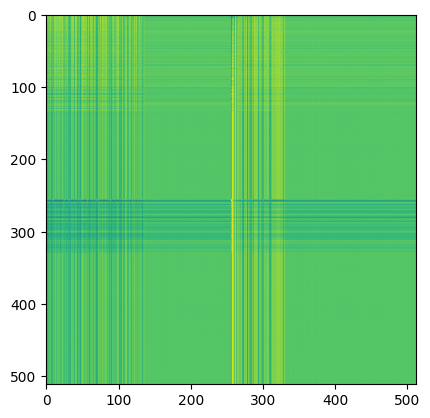

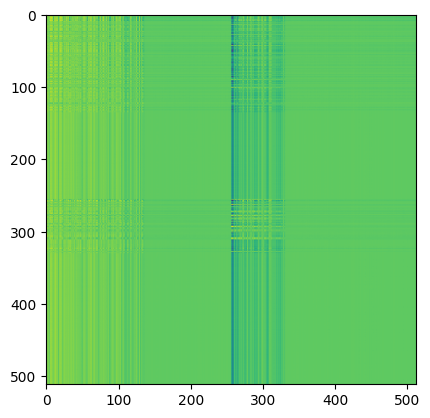

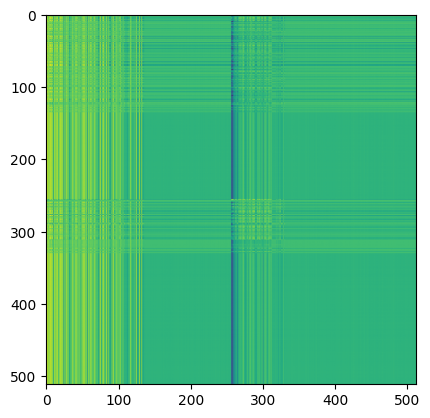

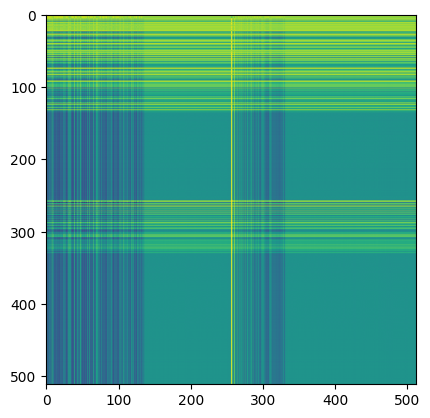

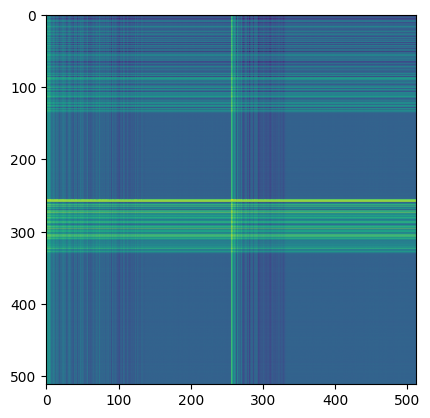

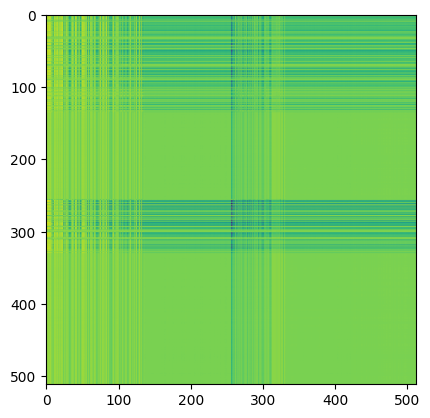

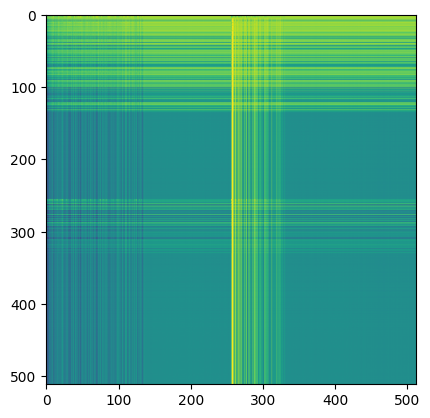

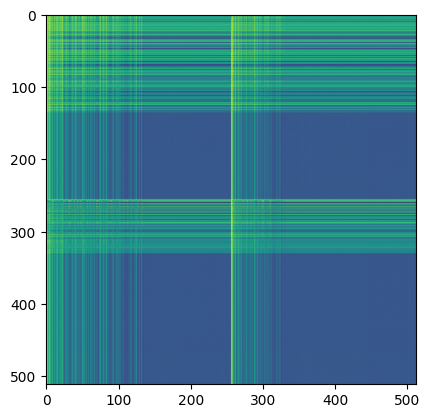

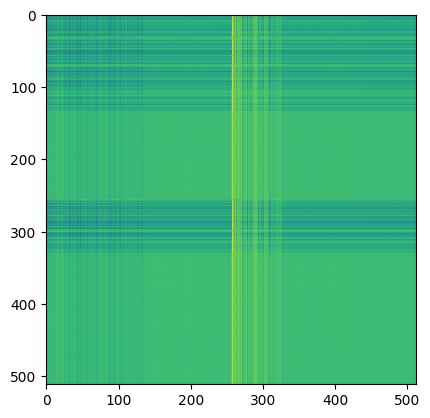

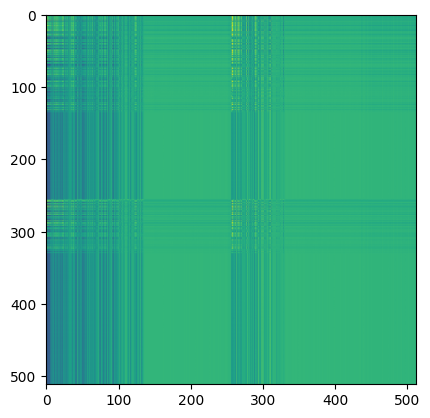

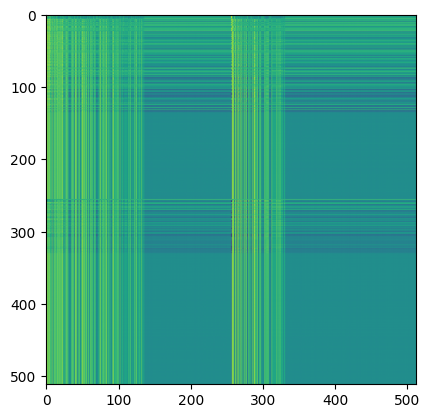

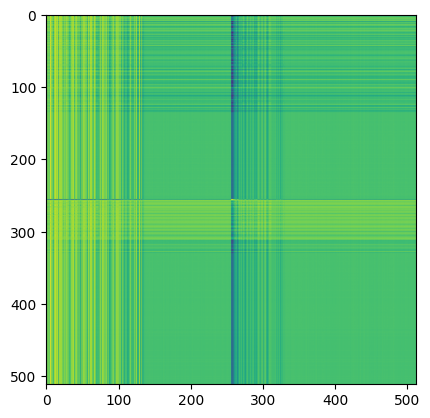

In [139]:
for i in range(4):
    plt.imshow(np.log(activation['attend1'][0,i,:,:].cpu().numpy()))
    plt.show()
    
for i in range(4):
    plt.imshow(np.log(activation['attend2'][0,i,:,:].cpu().numpy()))
    plt.show()

for i in range(4):
    plt.imshow(np.log(activation['attend3'][0,i,:,:].cpu().numpy()))
    plt.show()

for i in range(4):
    plt.imshow(np.log(activation['attend4'][0,i,:,:].cpu().numpy()))
    plt.show()

In [138]:

unequal = determinant_idx != stochastic_idx
print(unequal)
print(determinant_idx)
print(determinant_idx[unequal])

[[False False False False  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True 